# Sprint 2 Modelagem Matemática

O ChargeGrid Intelligence registra as sessões de recarga e pode aplicar políticas de cobrança dinâmica. Em um teste simplificado, a equipe observou que, quando a tarifa por kWh aumenta, a demanda tende a cair.  
Considere que a tarifa cobrada seja (p), em reais por kWh, e que o lucro diário estimado do eletroposto seja dado por:  

L(p) = -35p$^{2}$ + 298.5p - 406, para 1.5 ≤ p ≤ 6.5  

em que:
*   'p' é a tarifa cobrada por kWh;
*   'L(p)' é o lucro diário estimado, em reais;
*   o intervalo 1.5 ≤ p ≤ 6.5 representa os limites aceitáveis de tarifa definidos pela empresa.

In [ ]:
# Import de bibliotecas
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [ ]:
# intervalo
p_min = 1.5
p_max = 6.5

### Definindo as variaveis e funcoes
## simbolica (sympy)
# var p
p_sp = sp.symbols('p')
# funcao
l_sp = -(35 * p_sp ** 2) + (298.5 * p_sp) - 406

## numerica (numpy)
# intervalo de p
p = np.linspace(p_min, p_max, 50)
#funcao
def l(p):
  return -(35 * (p ** 2)) + (298.5 * p) - 406


## 1. Gráfico da Função e Valores Extremos

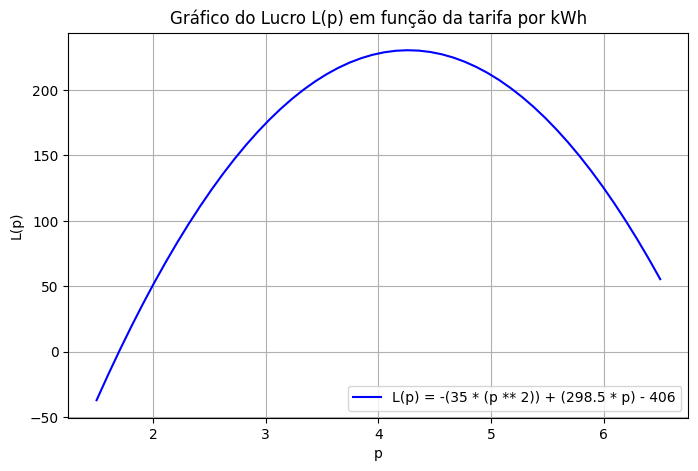


O lucro quando p é mínimo é igual a: R$-37.00

O lucro quando p é máximo é igual a: R$55.50


In [ ]:
# plot do grafico
plt.figure(figsize=(8,5))

plt.plot(p, l(p), label = "L(p) = -(35 * (p ** 2)) + (298.5 * p) - 406", color = "blue")

plt.title("Gráfico do Lucro L(p) em função da tarifa por kWh")
plt.xlabel("p")
plt.ylabel("L(p)")

plt.legend()
plt.grid()

plt.show()

# L(p) em p = 1.5
l_xmin = l_sp.subs(p_sp, p_min)
print(f"\nO lucro quando p é mínimo é igual a: R${l_xmin:.2f}")

#L(p) em p = 6.5
l_xmax = l_sp.subs(p_sp, p_max)
print(f"\nO lucro quando p é máximo é igual a: R${l_xmax:.2f}")

## 2. Derivada L'(p)

In [ ]:
# calculo
l_diff_sp = sp.diff(l_sp, p_sp)
l_diff = sp.lambdify(p_sp, l_diff_sp, 'numpy')

# mostrar
print("A derivada L'(p) de L(p) é: ")
display(l_diff_sp)

A derivada L'(p) de L(p) é: 


298.5 - 70*p

## 3. Pontos Críticos

Ponto(s) Critico(s): 4.26



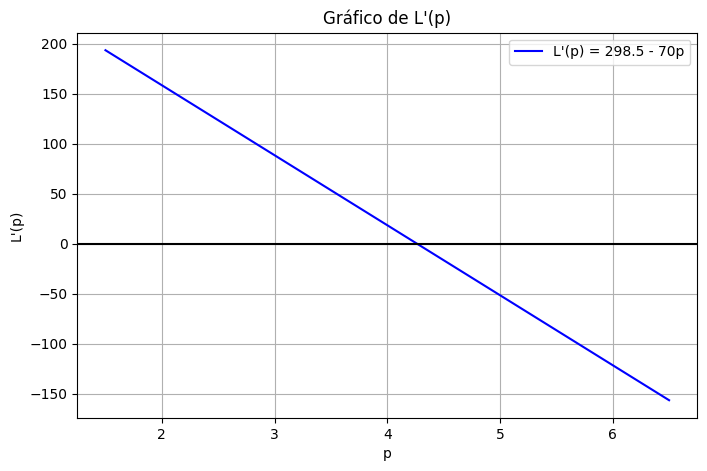

In [ ]:
# ponto critico é quando a derivada = 0
criticos = sp.solve(l_diff_sp, p_sp)
print(f"Ponto(s) Critico(s): {criticos[0]:.2f}\n")

# grafico da derivada
plt.figure(figsize=(8,5))

plt.plot(p, l_diff(p), label = "L'(p) = 298.5 - 70p", color = "blue")

plt.axhline(0, color='black')

plt.title("Gráfico de L'(p)")
plt.xlabel("p")
plt.ylabel("L'(p)")

plt.legend()
plt.grid()

plt.show()

## 4. Segunda Derivada L''(p)

L''(p) = -70


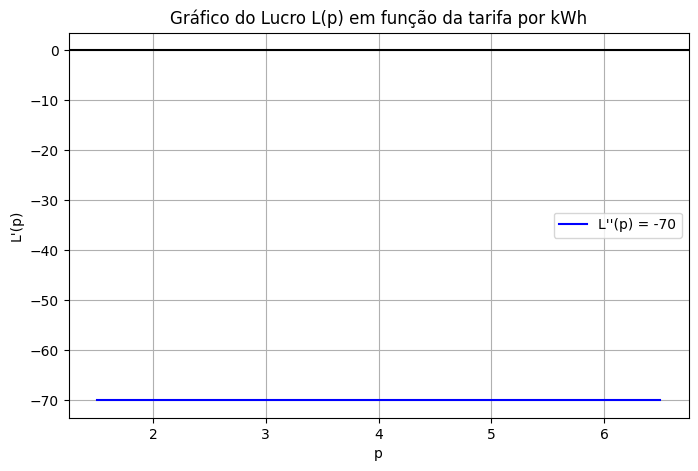

In [ ]:
# Calculo da segunda derivada
l_sec_diff = sp.diff(l_diff_sp, p_sp)
print("L''(p) =", l_sec_diff)

y = np.full_like(p, l_sec_diff)

#grafico
plt.figure(figsize=(8,5))

plt.plot(p, y, label = "L''(p) = -70", color = "blue")

plt.axhline(0, color='black')

plt.title("Gráfico de L''(p)")
plt.xlabel("p")
plt.ylabel("L'(p)")

plt.legend()
plt.grid()

plt.show()

## 5. Segunda Derivada L''(p) e Máximos e Mínimos

In [ ]:
# classificacao
if l_sec_diff < 0:
    print("O ponto crítico é um máximo local.")
elif l_sec_diff > 0:
    print("O ponto crítico é um mínimo local.")

# valores
l_xmin = l_sp.subs(p_sp, p_min)
l_xmax = l_sp.subs(p_sp, p_max)
l_critico = l_sp.subs(p_sp, criticos[0])

print("\nValores:")
print(f"L(1.5) = {l_xmin:.2f}")
print(f"L(6.5) = {l_xmax:.2f}")
print(f"L(p crítico) = {l_critico:.2f}")

# maximo e minimo global
valores = {
    1.5: l_xmin,
    6.5: l_xmax,
    criticos[0]: l_critico
}

maximo = max(valores, key=valores.get)
minimo = min(valores, key=valores.get)

print("\nMaximo global:")
print(f"p = {maximo:.2f} -> {valores[maximo]:.2f}")

print("\nMinimo global:")
print(f"p = {minimo:.2f} -> {valores[minimo]:.2f}")

O ponto crítico é um máximo local.

Valores:
L(1.5) = -37.00
L(6.5) = 55.50
L(p crítico) = 230.44

Maximo global:
p = 4.26 -> 230.44

Minimo global:
p = 1.50 -> -37.00


## Tarifa para Lucro Diário Máximo

Sendo o ponto crítico da função o máximo global, a tarifa escolhida deve ser igual, ou próxima, a tal valor.  
No caso, dentro do intervalo permitido pela empresa, a tarifa ideal para maximizar os lucros diários do eletroposto deve ser:  
***p ≈ 4.26***   
reais por kWh.